## Loading dan Standarisasi Dataset

In [22]:
import pandas as pd

df = pd.read_csv("train.csv").set_index("Id")
print(df.isna().sum())

df

Math            0
AdvancedMath    0
Physics         0
Chemistry       0
Biology         0
English         0
Indonesian      0
Accepted        0
dtype: int64


,Math,AdvancedMath,Physics,Chemistry,Biology,English,Indonesian,Accepted
Id,,,,,,,,
1,74.6,85.5,67.1,57.1,60.1,78.6,86.5,1
2,54.4,78.4,57.1,56.3,57.3,75.0,80.9,1
3,81.3,54.2,61.8,83.6,71.6,84.1,93.7,1
4,84.1,42.5,77.5,69.6,69.3,77.8,58.5,0
5,40.7,20.5,68.0,62.0,47.7,86.6,71.3,0
...,...,...,...,...,...,...,...,...
496,84.0,70.3,51.4,70.5,94.7,62.8,73.6,1
497,42.5,76.5,72.8,69.3,64.4,57.5,84.0,0
498,65.0,66.8,50.7,63.7,37.5,100.0,84.8,0


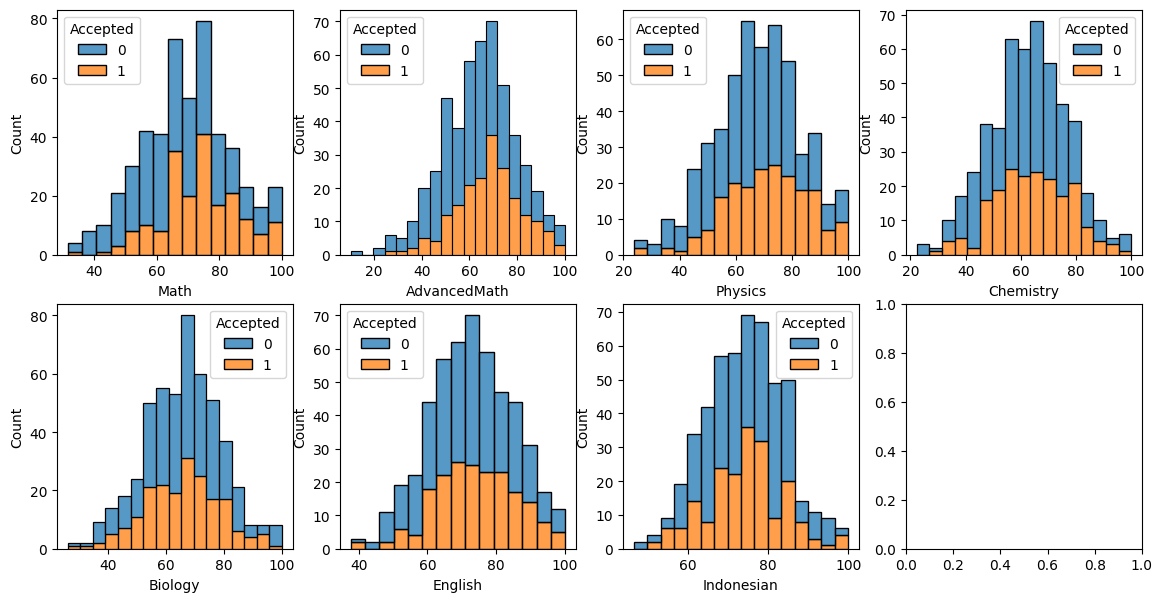

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(7):
    sns.histplot(x=df.iloc[:, i], hue=df.iloc[:, -1], ax=axes[i], multiple="stack")

In [24]:
x, y = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

## Membuat pipeline dan grid search

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer

en = ElasticNet()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

def featsel(z, count):
    return z[:, :count]

pipenb = make_pipeline(
    # StandardScaler(),
    # PowerTransformer(),
    # PCA(),
    FunctionTransformer(featsel),
    # SelectFromModel(en),
    GaussianNB(),
)
gscvnb = GridSearchCV(
    estimator=pipenb,
    param_grid={
        # "selectfrommodel__estimator__l1_ratio": [0.01, 0.25, 0.45, 0.5, 0.55, 0.75, 1.0],
        # "selectfrommodel__estimator__alpha": [0.001, 0.005, 0.01, 0.05, 0.1],
        "gaussiannb__var_smoothing": np.logspace(-2, 1, 20),
        # "pca__n_components": np.arange(1, 8),
        "functiontransformer__kw_args": [
            {"count": 1},
            {"count": 2},
            {"count": 3},
            {"count": 4},
            {"count": 5},
            {"count": 6},
            {"count": 7},
        ]
    },
    cv=skf,
    scoring="accuracy",
)
gscvnb.fit(x, y)
bestmodel = gscvnb.best_estimator_

print(gscvnb.best_score_)
print(gscvnb.best_params_)
pd.DataFrame(gscvnb.cv_results_).head()

0.674
{'functiontransformer__kw_args': {'count': 3}, 'gaussiannb__var_smoothing': np.float64(0.06158482110660264)}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_functiontransformer__kw_args,param_gaussiannb__var_smoothing,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003185,0.000269,0.002099,0.000250,{'count': 1},0.010000,"{'functiontransformer__kw_args': {'count': 1},...",0.57,0.61,0.63,0.61,0.61,0.606,0.019596,131
1,0.002756,0.000089,0.002208,0.000109,{'count': 1},0.014384,"{'functiontransformer__kw_args': {'count': 1},...",0.57,0.61,0.63,0.61,0.61,0.606,0.019596,131
2,0.002791,0.000244,0.002070,0.000437,{'count': 1},0.020691,"{'functiontransformer__kw_args': {'count': 1},...",0.57,0.61,0.63,0.61,0.61,0.606,0.019596,131
3,0.002574,0.000077,0.001812,0.000079,{'count': 1},0.029764,"{'functiontransformer__kw_args': {'count': 1},...",0.57,0.62,0.63,0.61,0.61,0.608,0.020396,129
4,0.002616,0.000069,0.001855,0.000077,{'count': 1},0.042813,"{'functiontransformer__kw_args': {'count': 1},...",0.57,0.61,0.62,0.60,0.61,0.602,0.017205,137


## Membuat prediksi menggunakan bestmodel

In [26]:
dfsub = pd.read_csv("test.csv").set_index("Id")
print(dfsub.isna().sum())
dfsub

Math            0
AdvancedMath    0
Physics         0
Chemistry       0
Biology         0
English         0
Indonesian      0
dtype: int64


,Math,AdvancedMath,Physics,Chemistry,Biology,English,Indonesian
Id,,,,,,,
501,65.2,77.4,57.2,58.1,56.0,57.4,72.3
502,96.4,41.6,64.2,35.3,79.1,65.7,60.7
503,56.4,64.0,32.7,77.9,60.5,76.0,72.0
504,59.0,56.5,64.9,68.4,51.8,68.7,61.4
505,55.5,54.8,59.8,60.6,65.4,72.4,55.5
...,...,...,...,...,...,...,...
996,48.4,77.1,30.8,74.3,51.9,67.3,77.6
997,76.3,76.9,76.5,57.2,71.2,76.1,75.5
998,75.8,93.6,65.6,64.0,51.5,77.6,73.3


In [27]:
xsub = dfsub.iloc[:, :].to_numpy()
ysubpred = bestmodel.predict(xsub)

sub = pd.Series(ysubpred, index=dfsub.index, name="Accepted")
sub.to_csv("submission.csv")
sub

Id
501     0
502     0
503     0
504     0
505     0
       ..
996     0
997     1
998     1
999     0
1000    0
Name: Accepted, Length: 500, dtype: int64